In [1]:
from ase.optimize import FIRE  
import numpy as np
from pathlib import Path
import csv


## Other default imports 

In [2]:
import os, re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
# from pymatgen.ext.matproj import MPRester
from mp_api.client import MPRester
from pymatgen.core import Composition, Element
from pymatgen.analysis.phase_diagram import GrandPotentialPhaseDiagram, PhaseDiagram
from pymatgen.analysis.interface_reactions import InterfacialReactivity, GrandPotentialInterfacialReactivity
from emmet.core.thermo import ThermoType
from pymatgen.entries.computed_entries import ComputedEntry
from matplotlib.patches import Patch
from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from pathlib import Path



In [4]:
%%capture
import siman #program package to manage DFT calculations https://github.com/dimonaks/siman
from siman.calc_manage import smart_structure_read, get_structure_from_matproj, get_structure_from_matproj_new
from siman.calc_manage import add, res
# Update configurations
from siman import header
from siman.database import write_database, read_database
from siman.set_functions import read_vasp_sets
from siman.header import db
from siman.header import _update_configuration
_update_configuration('project_conf.py')
read_database() # read saved database if available
from pydoc import importfile
project_sets = importfile('project_sets.py')
varset = read_vasp_sets(project_sets.user_vasp_sets, override_global = 0) #read user sets

from siman import thermo

# header.PATH2PROJECT = '../dft_calculations/'
header.PATH2EDITOR = 'notepad.exe'
header.PATH2POTENTIALS = "/home/a.burov/soft/vasp_potentials/potpaw_PBE_MPIE/"

from matplotlib import rc



In [5]:
from ase.optimize import FIRE  
from ase.io import read, write
from ase.visualize import view


In [6]:
from matplotlib import font_manager as fm
font_path = "/home/a.burov/fonts/ARIAL.TTF"
fm.fontManager.addfont(font_path)


In [7]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [8]:
np.set_printoptions(precision=5)


In [9]:
# %matplotlib inline
plt.rcParams['figure.dpi'] = 450


In [10]:
API_KEY = "LTSM6dStBrl69FjopxP7KdZBP35B1yh7"

## DFT Calculations

### Layered

In [11]:
def generate_substitutions(struct):
    """Generate all F ↔ O-H exchange configurations"""
    configs = []
    
    # Identify anion sites (O=8-11, F=12-15)
    O_sites = [8, 9, 10, 11]
    F_sites = [12, 13, 14, 15]
    
    from itertools import combinations
    
    # All possible exchanges (1:1 substitution)
    for n_sub in range(1, 5):  # 1 to 4 exchanges
        for f_idx in combinations(F_sites, n_sub):
            for o_idx in combinations(O_sites, n_sub):
                new_struct = struct.copy()
                
                # Exchange: F → O, O → F at selected sites
                for i, j in zip(f_idx, o_idx):
                    new_struct.replace(i, "O")   # F site → O
                    new_struct.replace(j, "F")   # O site → F
                
                # Check uniqueness (avoid duplicates)
                new_struct.get_sorted_structure()
                configs.append(new_struct)
    
    return configs



In [12]:
st_layered = smart_structure_read("/home/a.burov/icys_2025/niohf/initial_no_relaxation/CuOHF.cif")

In [13]:
st_layered.printme()

Full Formula (Cu4 H4 O4 F4)
Reduced Formula: CuHOF
abc   :   5.301000   6.376000   5.074000
angles:  90.000000 112.900000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP          a        b        c
---  ----  -------  -------  -------
  0  Cu    0.75725  0.3775   0.99112
  1  Cu    0.74275  0.8775   0.00888
  2  Cu    0.24275  0.6225   0.00888
  3  Cu    0.25725  0.1225   0.99112
  4  H     0.698    0.131    0.337
  5  H     0.802    0.631    0.663
  6  H     0.302    0.869    0.663
  7  H     0.198    0.369    0.337
  8  O     0.6611   0.13548  0.1783
  9  O     0.8389   0.63548  0.8217
 10  O     0.3389   0.86452  0.8217
 11  O     0.1611   0.36452  0.1783
 12  F     0.8721   0.11643  0.7381
 13  F     0.6279   0.61643  0.2619
 14  F     0.1279   0.88357  0.2619
 15  F     0.3721   0.38357  0.7381


In [14]:
st_pmg = st_layered.convert2pymatgen()

In [14]:
new_configs = generate_substitutions(st_pmg)
print(f"Generated {len(new_configs)} configurations")


Generated 69 configurations


In [15]:
from pymatgen.analysis.structure_matcher import StructureMatcher
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

In [16]:
def aggressive_filter(configs):
    """Reduce 69 → 5-10 unique structures (fixed API)"""
    unique = []
    
    for config in configs:
        # 1. Niggli reduction
        reduced = config.get_reduced_structure(reduction_algo="niggli")
        
        # 2. Skip if already in unique list
        is_duplicate = False
        for u in unique:
            u_reduced = u.get_reduced_structure(reduction_algo="niggli")
            
            # Fixed: rmsd_cutoff instead of tolerance
            matcher = StructureMatcher(
                primitive_cell=True, 
                # scale=True,
                scale=False, 
                ltol=0.3,  
                stol=0.5,
                angle_tol=5,
                attempt_supercell=False
            )
            if matcher.fit(reduced, u_reduced):
                is_duplicate = True
                break
        
        if not is_duplicate:
            unique.append(config)
    
    return unique


In [17]:
def fast_symmetry_filter(configs):
    """Ultra-fast symmetry reduction using spacegroup"""
    seen = {}
    unique = []
    
    for i, config in enumerate(configs):
        sg = SpacegroupAnalyzer(config)
        sg_key = sg.get_space_group_symbol()
        formula = config.formula
        
        key = f"{formula}_{sg_key}"
        
        if key not in seen:
            seen[key] = True
            unique.append(config)
            print(f"Added: {formula} | {sg_key}")
    
    return unique

In [18]:
unique_configs = fast_symmetry_filter(new_configs)
print(f"Unique by symmetry: {len(unique_configs)}")


Added: Cu4 H4 O4 F4 | P1
Added: Cu4 H4 O4 F4 | P2_1
Added: Cu4 H4 O4 F4 | P-1
Added: Cu4 H4 O4 F4 | Pc
Added: Cu4 H4 O4 F4 | P2_1/c
Unique by symmetry: 5


In [19]:
from siman.core.structure import Structure as base_siman_structure

In [20]:
for st_refined in unique_configs:
    sp_gr = st_refined.get_symmetry_dataset()['international']
    sp_gr = sp_gr.replace("/", "_")
    st_siman = base_siman_structure().update_from_pymatgen(stpm=st_refined)

    els = st_siman.get_elements()
    els_ni = [idx for idx, el in enumerate(els) if el == "Cu"]
    st_siman = st_siman.replace_atoms(els_ni, "Ni")

    print(st_siman.get_formula(), sp_gr)

    if 0:
        st_siman.write_poscar(f"/home/a.burov/icys_2025/niohf/initial_no_relaxation/layered/layered_{sp_gr}.POSCAR")
        st_siman.write_cif(f"/home/a.burov/icys_2025/niohf/initial_no_relaxation/layered/layered_{sp_gr}")

    # add(f"layered_{sp_gr}", '9bulk_eos', 1, it_folder = 'layered', input_st = st_siman, calc_method = 'c_scale', 
				# n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128', up='up2', run=2)
    # add(f"layered_{sp_gr}", '9bulk_eos', 1, it_folder = 'layered', input_st = st_siman, calc_method = 'uniform_scale', 
				# n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128', up='up2', run=2)
    # add(f"layered_{sp_gr}", '9bulk', 1, it_folder = 'layered', input_st = st_siman, cluster = 'razor128', up='up2', run=2)

    # res(f"layered_{sp_gr}.su", '9bulk_eos', list(range(1,11)) + [100], show = 'fit', analys_type = 'fit_a', up="up2", cluster = 'razor128')
    # res(f"layered_{sp_gr}.sc", '9bulk_eos', list(range(1,11)) + [100], show = 'fit', analys_type = 'fit_a', up="up2", cluster = 'razor128')
    # res(f"layered_{sp_gr}", '9bulk', 1, cluster = 'razor128', )

    st = db[f"layered_{sp_gr}", '9bulk', 1].copy().end
    # add(f"layered_{sp_gr}_rel", '9bulk_eos', 1, it_folder = 'layered', input_st = st, calc_method = 'c_scale', 
				# n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128', up='up2', run=2)
    # add(f"layered_{sp_gr}_rel", '9bulk_eos', 1, it_folder = 'layered', input_st = st, calc_method = 'uniform_scale', 
				# n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128', up='up2', run=2)
    
    # res(f"layered_{sp_gr}_rel.sc", '9bulk_eos', list(range(1,11)) + [100], show = 'fit', analys_type = 'fit_a', up="up2", cluster = 'razor128')
    # res(f"layered_{sp_gr}_rel.su", '9bulk_eos', list(range(1,11)) + [100], show = 'fit', analys_type = 'fit_a', up="up2", cluster = 'razor128')

    st = db[f"layered_{sp_gr}_rel.sc", '9bulk_eos', 100].copy().end
    # add(f"layered_{sp_gr}_final", '9bulk', 1, it_folder = 'layered', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{sp_gr}_final", '9bulk', 1, cluster = 'razor128', up='up2', )


    # check calcs
    # add(f"layered_{sp_gr}_final", '9bulk_fine', 1, it_folder = 'layered', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{sp_gr}_final", '9bulk_fine', 1, cluster = 'razor128', up='up2', )

    # add(f"layered_{sp_gr}_final_su", '9bulk_fine_vdw', 1, it_folder = 'layered', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{sp_gr}_final_su", '9bulk_fine_vdw', 1, cluster = 'razor128', up='up2', )

    # add(f"layered_{sp_gr}_final_su", '9bulk_fine_rel_vdw', 1, it_folder = 'layered', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{sp_gr}_final_su", '9bulk_fine_rel_vdw', 1, cluster = 'razor128', up='up2', )
    
    st = db[f"layered_{sp_gr}_rel.su", '9bulk_eos', 100].copy().end
    # add(f"layered_{sp_gr}_final_su", '9bulk', 1, it_folder = 'layered', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{sp_gr}_final_su", '9bulk', 1, cluster = 'razor128', up='up2', )

    # add(f"layered_{sp_gr}_final_su", '9bulk_fine', 1, it_folder = 'layered', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{sp_gr}_final_su", '9bulk_fine', 1, cluster = 'razor128', up='up2', )

    # add(f"layered_{sp_gr}_final_su", '9bulk_fine_rel', 1, it_folder = 'layered', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{sp_gr}_final_su", '9bulk_fine_rel', 1, cluster = 'razor128', up='up2', )


Ni4 H4 O4 F4 P1
Ni4 H4 O4 F4 P2_1
Ni4 H4 O4 F4 P-1
Ni4 H4 O4 F4 Pc
Ni4 H4 O4 F4 P2_1_c


In [21]:
write_database()


Database has been successfully updated



In [22]:
els = st_layered.get_elements()
els_ni = [idx for idx, el in enumerate(els) if el == "Cu"]

In [23]:
st_layered = st_layered.replace_atoms(els_ni, "Ni")

In [24]:
# add("layered", '9bulk_eos', 1, it_folder = 'layered', input_st = st_layered, calc_method = 'c_scale', 
# 				n_scale_images=10, scale_region = (-5, 5), cluster = 'razor128', up='up2', run=2)

# res("layered.sc", '9bulk_eos', list(range(1,11)) + [100], show = 'fit', analys_type = 'fit_a', 
#         up="up2", cluster = 'razor128')


In [25]:
st_rel = db["layered.sc", '9bulk_eos', 100].copy().end


In [26]:
# add("layered", '9bulk', 1, it_folder = 'layered', input_st = st_rel, cluster = 'razor128', up='up2', run=2)


In [27]:
# res("layered", '9bulk', 1, cluster = 'razor128', )


### Diaspore

In [28]:
st_alpha = smart_structure_read("/home/a.burov/icys_2025/niohf/initial_no_relaxation/diaspore_NiOHF_alpha.POSCAR")
st_beta = smart_structure_read("/home/a.burov/icys_2025/niohf/initial_no_relaxation/diaspore_NiOHF_beta.POSCAR")
st_gamma = smart_structure_read("/home/a.burov/icys_2025/niohf/initial_no_relaxation/diaspore_NiOHF_gamma.POSCAR")
st_delta = smart_structure_read("/home/a.burov/icys_2025/niohf/initial_no_relaxation/diaspore_NiOHF_delta.POSCAR")


In [29]:
# add("alpha", '9bulk_eos', 1, it_folder = 'diaspore', input_st = st_alpha, calc_method = 'c_scale', 
# 				n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128', up='up2', run=2)


In [30]:
# add("beta", '9bulk_eos', 1, it_folder = 'diaspore', input_st = st_beta, calc_method = 'c_scale', 
# 				n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128', up='up2', run=2)


In [31]:
# add("gamma", '9bulk_eos', 1, it_folder = 'diaspore', input_st = st_gamma, calc_method = 'c_scale', 
# 				n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128', up='up2', run=2)


In [32]:
# add("delta", '9bulk_eos', 1, it_folder = 'diaspore', input_st = st_delta, calc_method = 'c_scale', 
# 				n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128', up='up2', run=2)


In [33]:
for st_name in ["alpha", "beta", "gamma", "delta"]:
    # res(f"{st_name}.sc", '9bulk_eos', list(range(1,11)) + [100], show = 'fit', analys_type = 'fit_a', up="up2", cluster = 'razor128')
    en = db[f"{st_name}.sc", '9bulk_eos', 100].e0_at
    
    print(f"{st_name}: {en:1.3f}")
    

alpha: -4.842
beta: -4.850
gamma: -4.809
delta: -4.853


In [34]:
write_database()


Database has been successfully updated



## Write DFT energies in CSV

In [35]:
layered_groups = ["P1", "P2_1", "P-1", "Pc", "P2_1_c"]

names_list = ["layered_p1", "layered_p-1", "layered_p21", "layered_p2c",
    "layered_p21c", "alpha", "beta", "gamma", "delta"]


In [36]:
energies = []

for group in layered_groups:
    if (group == "P2_1_c"):
        calc = db[f"layered_{group}_final_su", '9bulk', 1]
    else:
        calc = db[f"layered_{group}_final", '9bulk', 1]
        
    energies.append(calc.e0)

for st_name in ["alpha", "beta", "gamma", "delta"]:
    en = db[f"{st_name}.sc", '9bulk_eos', 100].e0
    energies.append(en)
    

In [37]:
energies

[-77.72626401,
 -77.72609138,
 -77.68031333,
 -77.75002784,
 -77.73777965,
 -77.4780561,
 -77.59317385,
 -76.9403401,
 -77.6547886]

In [38]:
path_energies_dft = '/home/a.burov/icys_2025/niohf/optimized/energies_dft.csv'


In [39]:
# choose keys and order
fieldnames = ['name', 'energy_dft']

rows = []


with open(path_energies_dft, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(fieldnames)
    for idx in range(len(energies)):
        w.writerow([names_list[idx], energies[idx], ])
        

    

## Calculated energies

In [40]:
import pandas as pd

In [245]:
path_data = "/home/a.burov/icys_2025/niohf/optimized/"

In [246]:
data_all = {
    "dft": [],
    "mace": [],
    "grace": [],
    "mattersim": [],
    "sevennet": [],
    "chgnet": [],
    "nequip": [],
    "alignn": [],
    "m3gnet": [],
    "upet": [],
    "fairchem": [],
}


In [247]:
for type_calc in data_all.keys():
    data_path = f"{path_data}/energies_{type_calc}.csv"
    
    data = pd.read_csv(data_path)
    names = data["name"].to_list()
    values = np.array(data[f"energy_{type_calc}"].to_list()) / 16

    data_all[type_calc] = values
    
    

In [248]:
data_all

{'dft': array([-4.85789, -4.85788, -4.85502, -4.85938, -4.85861, -4.84238,
        -4.84957, -4.80877, -4.85342]),
 'mace': array([-4.7668 , -4.76645, -4.76762, -4.76519, -4.76755, -4.7578 ,
        -4.75673, -4.72329, -4.75611]),
 'grace': array([-4.72523, -4.72235, -4.72517, -4.72737, -4.72524, -4.70817,
        -4.71864, -4.67157, -4.73119]),
 'mattersim': array([-4.77853, -4.77649, -4.77837, -4.7811 , -4.77822, -4.76347,
        -4.7666 , -4.7171 , -4.7707 ]),
 'sevennet': array([-4.78281, -4.78192, -4.78613, -4.7781 , -4.78595, -4.77422,
        -4.76953, -4.7251 , -4.76775]),
 'chgnet': array([-5.65948, -5.65721, -5.65925, -5.66035, -5.65938, -5.65708,
        -5.66282, -5.63306, -5.66414]),
 'nequip': array([-4.75202, -4.75096, -4.75102, -4.75473, -4.75093, -4.74181,
        -4.75039, -4.70358, -4.75568]),
 'alignn': array([-5.58044, -5.56395, -5.58653, -5.55481, -5.57889, -5.57396,
        -5.559  , -5.57319, -5.56571]),
 'm3gnet': array([-4.73229, -4.73107, -4.73207, -4.73392,

In [249]:
# normalize energies
for type_calc, val in data_all.items():
    data_all[type_calc] = val - min(val)


In [250]:
names

['layered_p1',
 'layered_p-1',
 'layered_p21',
 'layered_p2c',
 'layered_p21c',
 'alpha',
 'beta',
 'gamma',
 'delta']

In [251]:
colors = {
    "dft": "green",
    "mace": 'red',
    "grace": 'blue',
    "mattersim": 'magenta',
    "sevennet": 'black',
    "chgnet": 'orange',
    "alignn": "orchid",
    "m3gnet": "olive",
    "upet": "darkcyan",
    "fairchem": "indigo",
    "nequip": "maroon",
}


In [252]:
names_plot = [
                r"$P1$-L",
                r"$P\overline{1}$-L", 
                r"$P2_1$-L", 
                r"$P2/c$-L", 
                r"$P2_1/c$-L",  
              r"$\alpha$-F", 
              r"$\beta$-F", 
              r"$\gamma$-F", 
              r"$\delta$-F"
]



/tmp/ipykernel_2426231/1549155457.py:33: UserWarning: You passed a edgecolor/edgecolors ('green') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(zero_positions, np.zeros(len(zero_positions))+1.1, marker='x', s=15,
/tmp/ipykernel_2426231/1549155457.py:33: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(zero_positions, np.zeros(len(zero_positions))+1.1, marker='x', s=15,
/tmp/ipykernel_2426231/1549155457.py:33: UserWarning: You passed a edgecolor/edgecolors ('blue') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(zero_positions, np.zeros(len(zero_positions))+1.1, marker='x', s=15,
/tmp/ipykernel_2426231/1549155457.py:33: UserWarning: Y

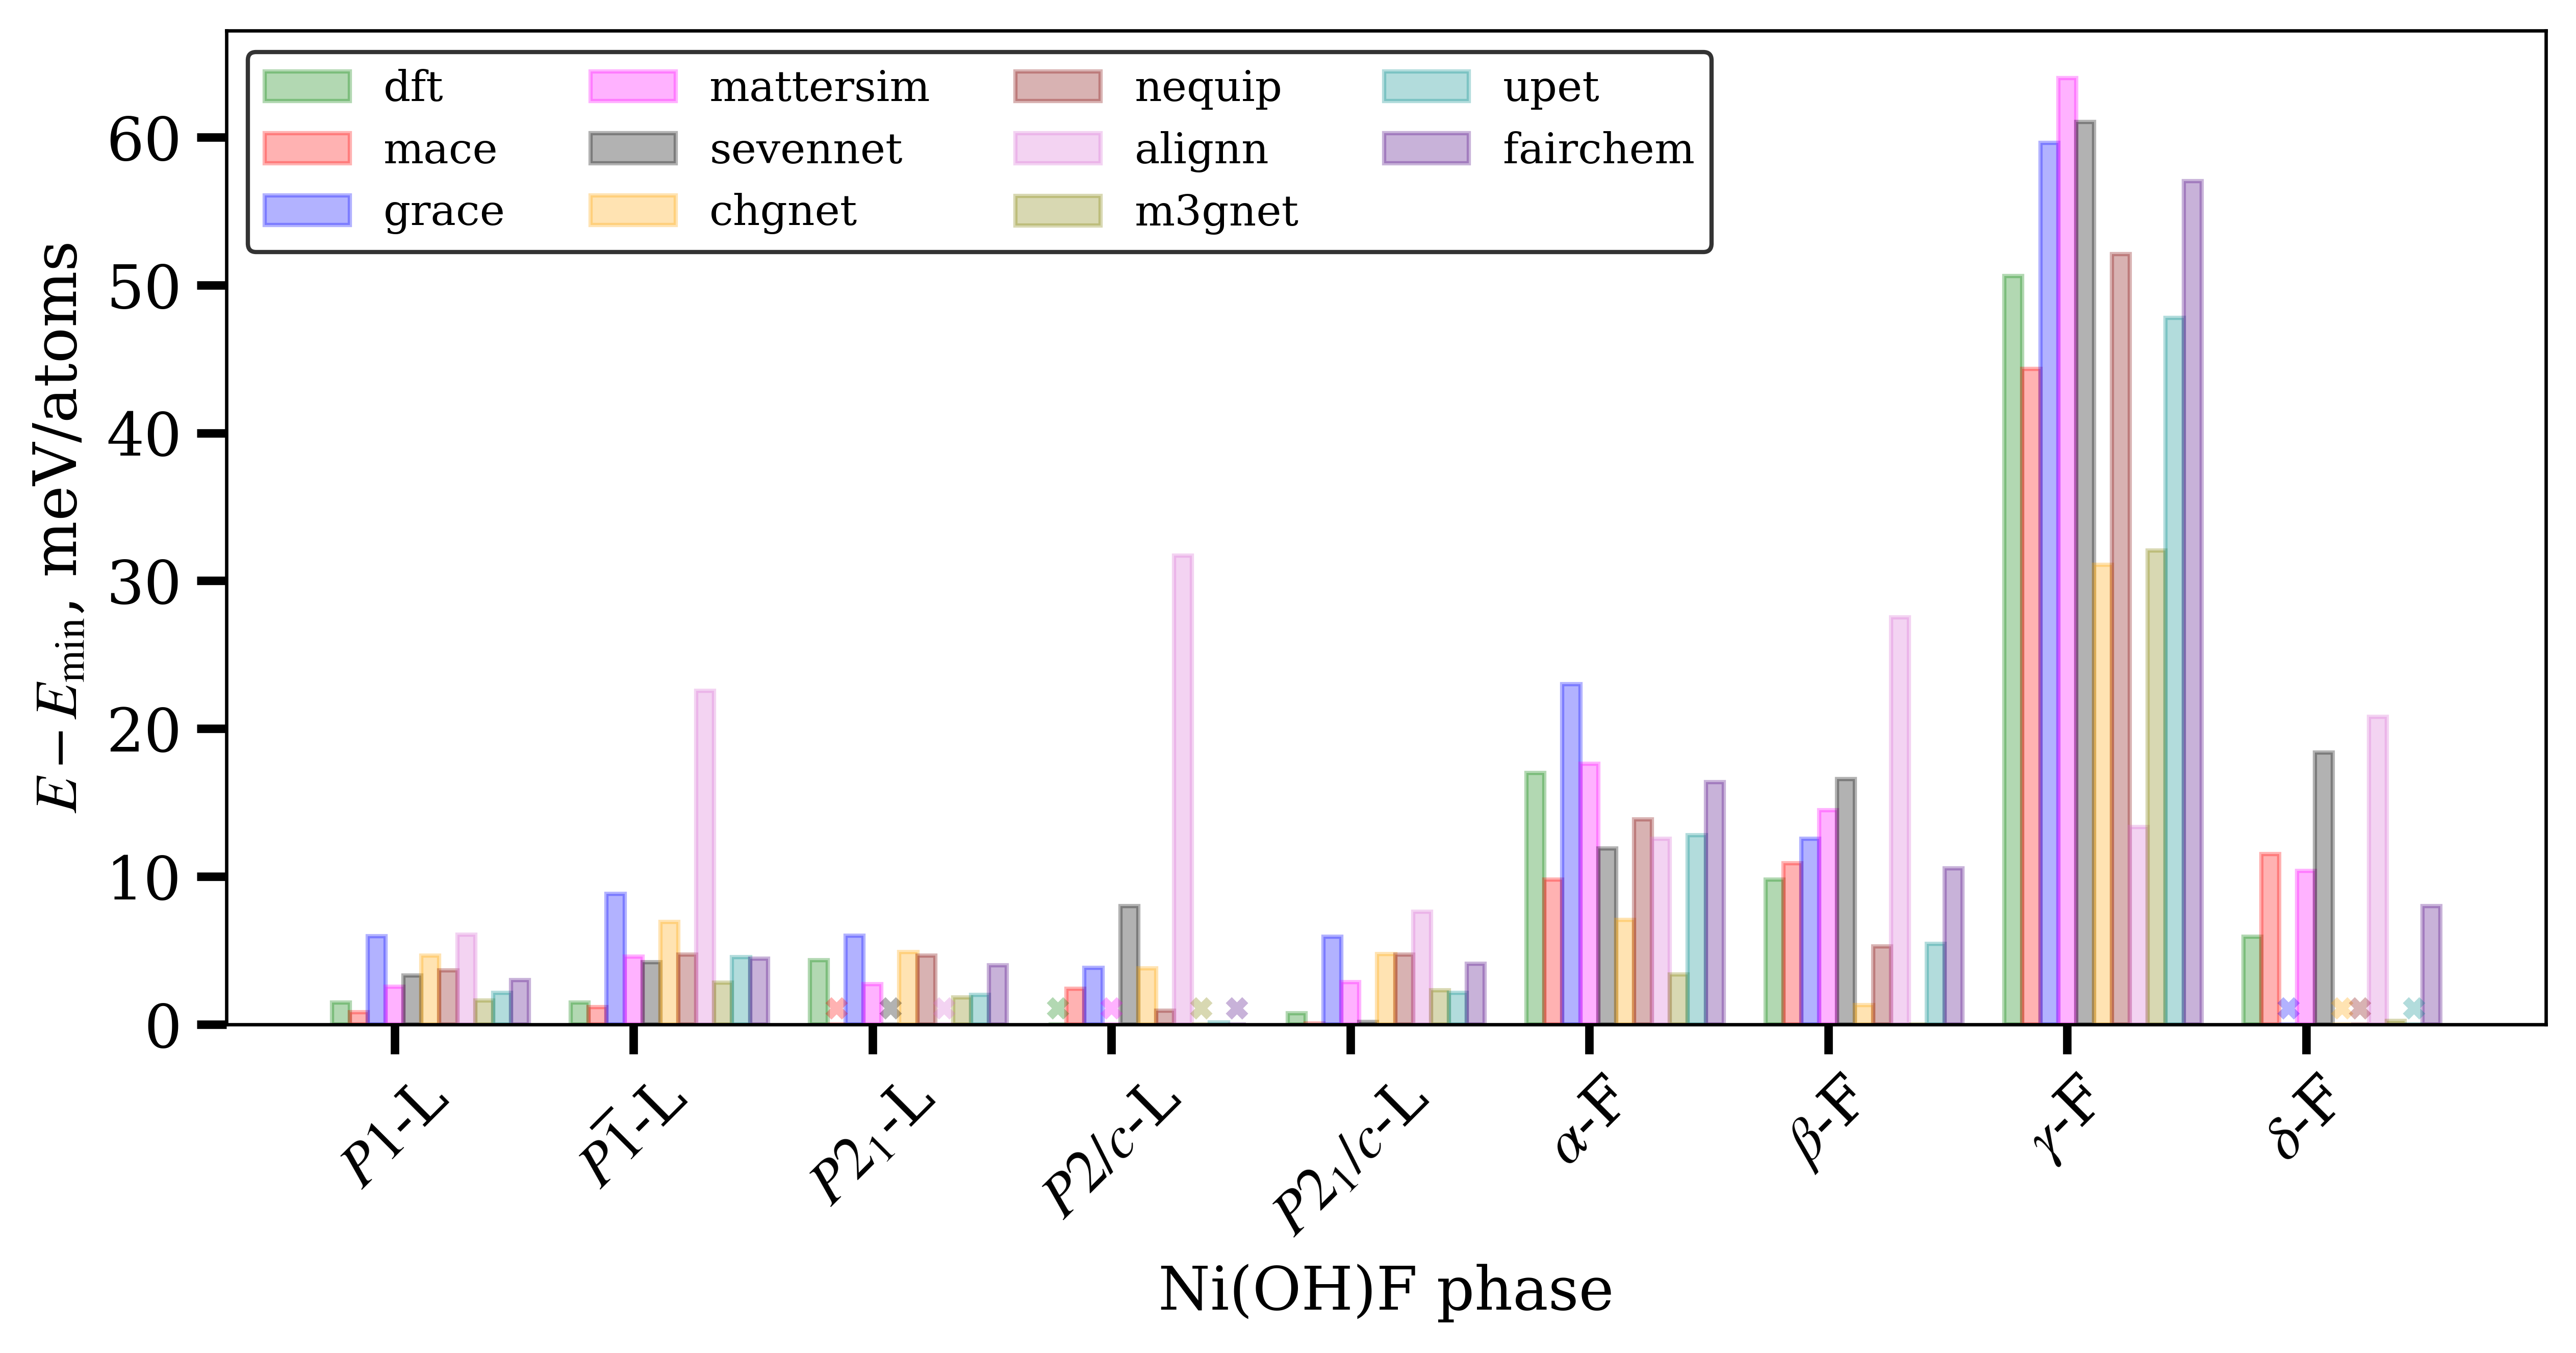

In [262]:
fontsize = 14
lw = 2.0

fig, ax = plt.subplots(1, 1, figsize=(9, 5), dpi=600)
plt.tight_layout()


# Add titles and labels
ax.set_ylabel(r'$E - E_{\mathrm{min}}$, meV/atoms', fontsize=fontsize)
ax.set_xlabel(r'Ni(OH)F phase', fontsize=fontsize)

ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.tick_params(axis='both', which='minor', labelsize=fontsize-2)
ax.yaxis.get_offset_text().set_fontsize(10)
ax.xaxis.set_tick_params(width=2, length=7)
ax.yaxis.set_tick_params(width=2, length=7)

length = len(names)
ax.set_xticks(range(length), names_plot, rotation=45)
idx_list = np.array(range(length))
shift = - (length // 2) + (length % 2)  # initial shift for bars
width = 0.075

for idx, (type_calc, val) in enumerate(data_all.items()):
    data_plot = data_all[type_calc]
    ax.bar(idx_list + width*(shift+idx), data_plot*1e3, width=width, color=colors[type_calc],
                           edgecolor=colors[type_calc], alpha=0.3, label=type_calc)

    # Add crosses for zero energy structures
    zero_mask = np.array(data_plot) == 0
    zero_positions = idx_list[zero_mask] + width*(shift+idx)
    if len(zero_positions) > 0:
        ax.scatter(zero_positions, np.zeros(len(zero_positions))+1.1, marker='x', s=15, 
                   color=colors[type_calc], linewidths=2, zorder=10, alpha=0.3, edgecolor=colors[type_calc])


ax.legend(fontsize=fontsize-4, edgecolor="black", ncols=length//2)

fig.tight_layout()

plt.show()

# fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/energies.png", bbox_inches='tight', dpi=450)
# fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/energies.pdf", bbox_inches='tight', dpi=450)

fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/energies.png", dpi=450)
fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/energies.pdf", dpi=450)




## Map of guesses

In [263]:
data_all

{'dft': array([0.00149, 0.0015 , 0.00436, 0.     , 0.00077, 0.017  , 0.0098 ,
        0.05061, 0.00595]),
 'mace': array([8.23886e-04, 1.17224e-03, 0.00000e+00, 2.43044e-03, 6.87032e-05,
        9.82166e-03, 1.08982e-02, 4.43316e-02, 1.15158e-02]),
 'grace': array([0.00596, 0.00884, 0.00602, 0.00383, 0.00596, 0.02302, 0.01255,
        0.05962, 0.     ]),
 'mattersim': array([0.00258, 0.00461, 0.00273, 0.     , 0.00289, 0.01763, 0.0145 ,
        0.064  , 0.0104 ]),
 'sevennet': array([0.00332, 0.00421, 0.     , 0.00803, 0.00018, 0.01191, 0.01659,
        0.06103, 0.01838]),
 'chgnet': array([0.00466, 0.00693, 0.0049 , 0.00379, 0.00476, 0.00706, 0.00132,
        0.03109, 0.     ]),
 'nequip': array([0.00365, 0.00472, 0.00465, 0.00095, 0.00474, 0.01386, 0.00529,
        0.0521 , 0.     ]),
 'alignn': array([0.00609, 0.02258, 0.     , 0.03172, 0.00764, 0.01257, 0.02752,
        0.01334, 0.02082]),
 'm3gnet': array([1.62287e-03, 2.84413e-03, 1.84444e-03, 0.00000e+00, 2.31162e-03,
        3.

In [264]:
list(data_all.keys())

['dft',
 'mace',
 'grace',
 'mattersim',
 'sevennet',
 'chgnet',
 'nequip',
 'alignn',
 'm3gnet',
 'upet',
 'fairchem']

In [265]:
names_calc = list(data_all.keys())

In [266]:
names_plot = [
    # "",
    '$P1$-L',
 '$P\\overline{1}$-L',
 '$P2_1$-L',
 '$P2/c$-L',
 '$P2_1/c$-L',
 '$\\alpha$-F',
 '$\\beta$-F',
 '$\\gamma$-F',
 '$\\delta$-F'
]



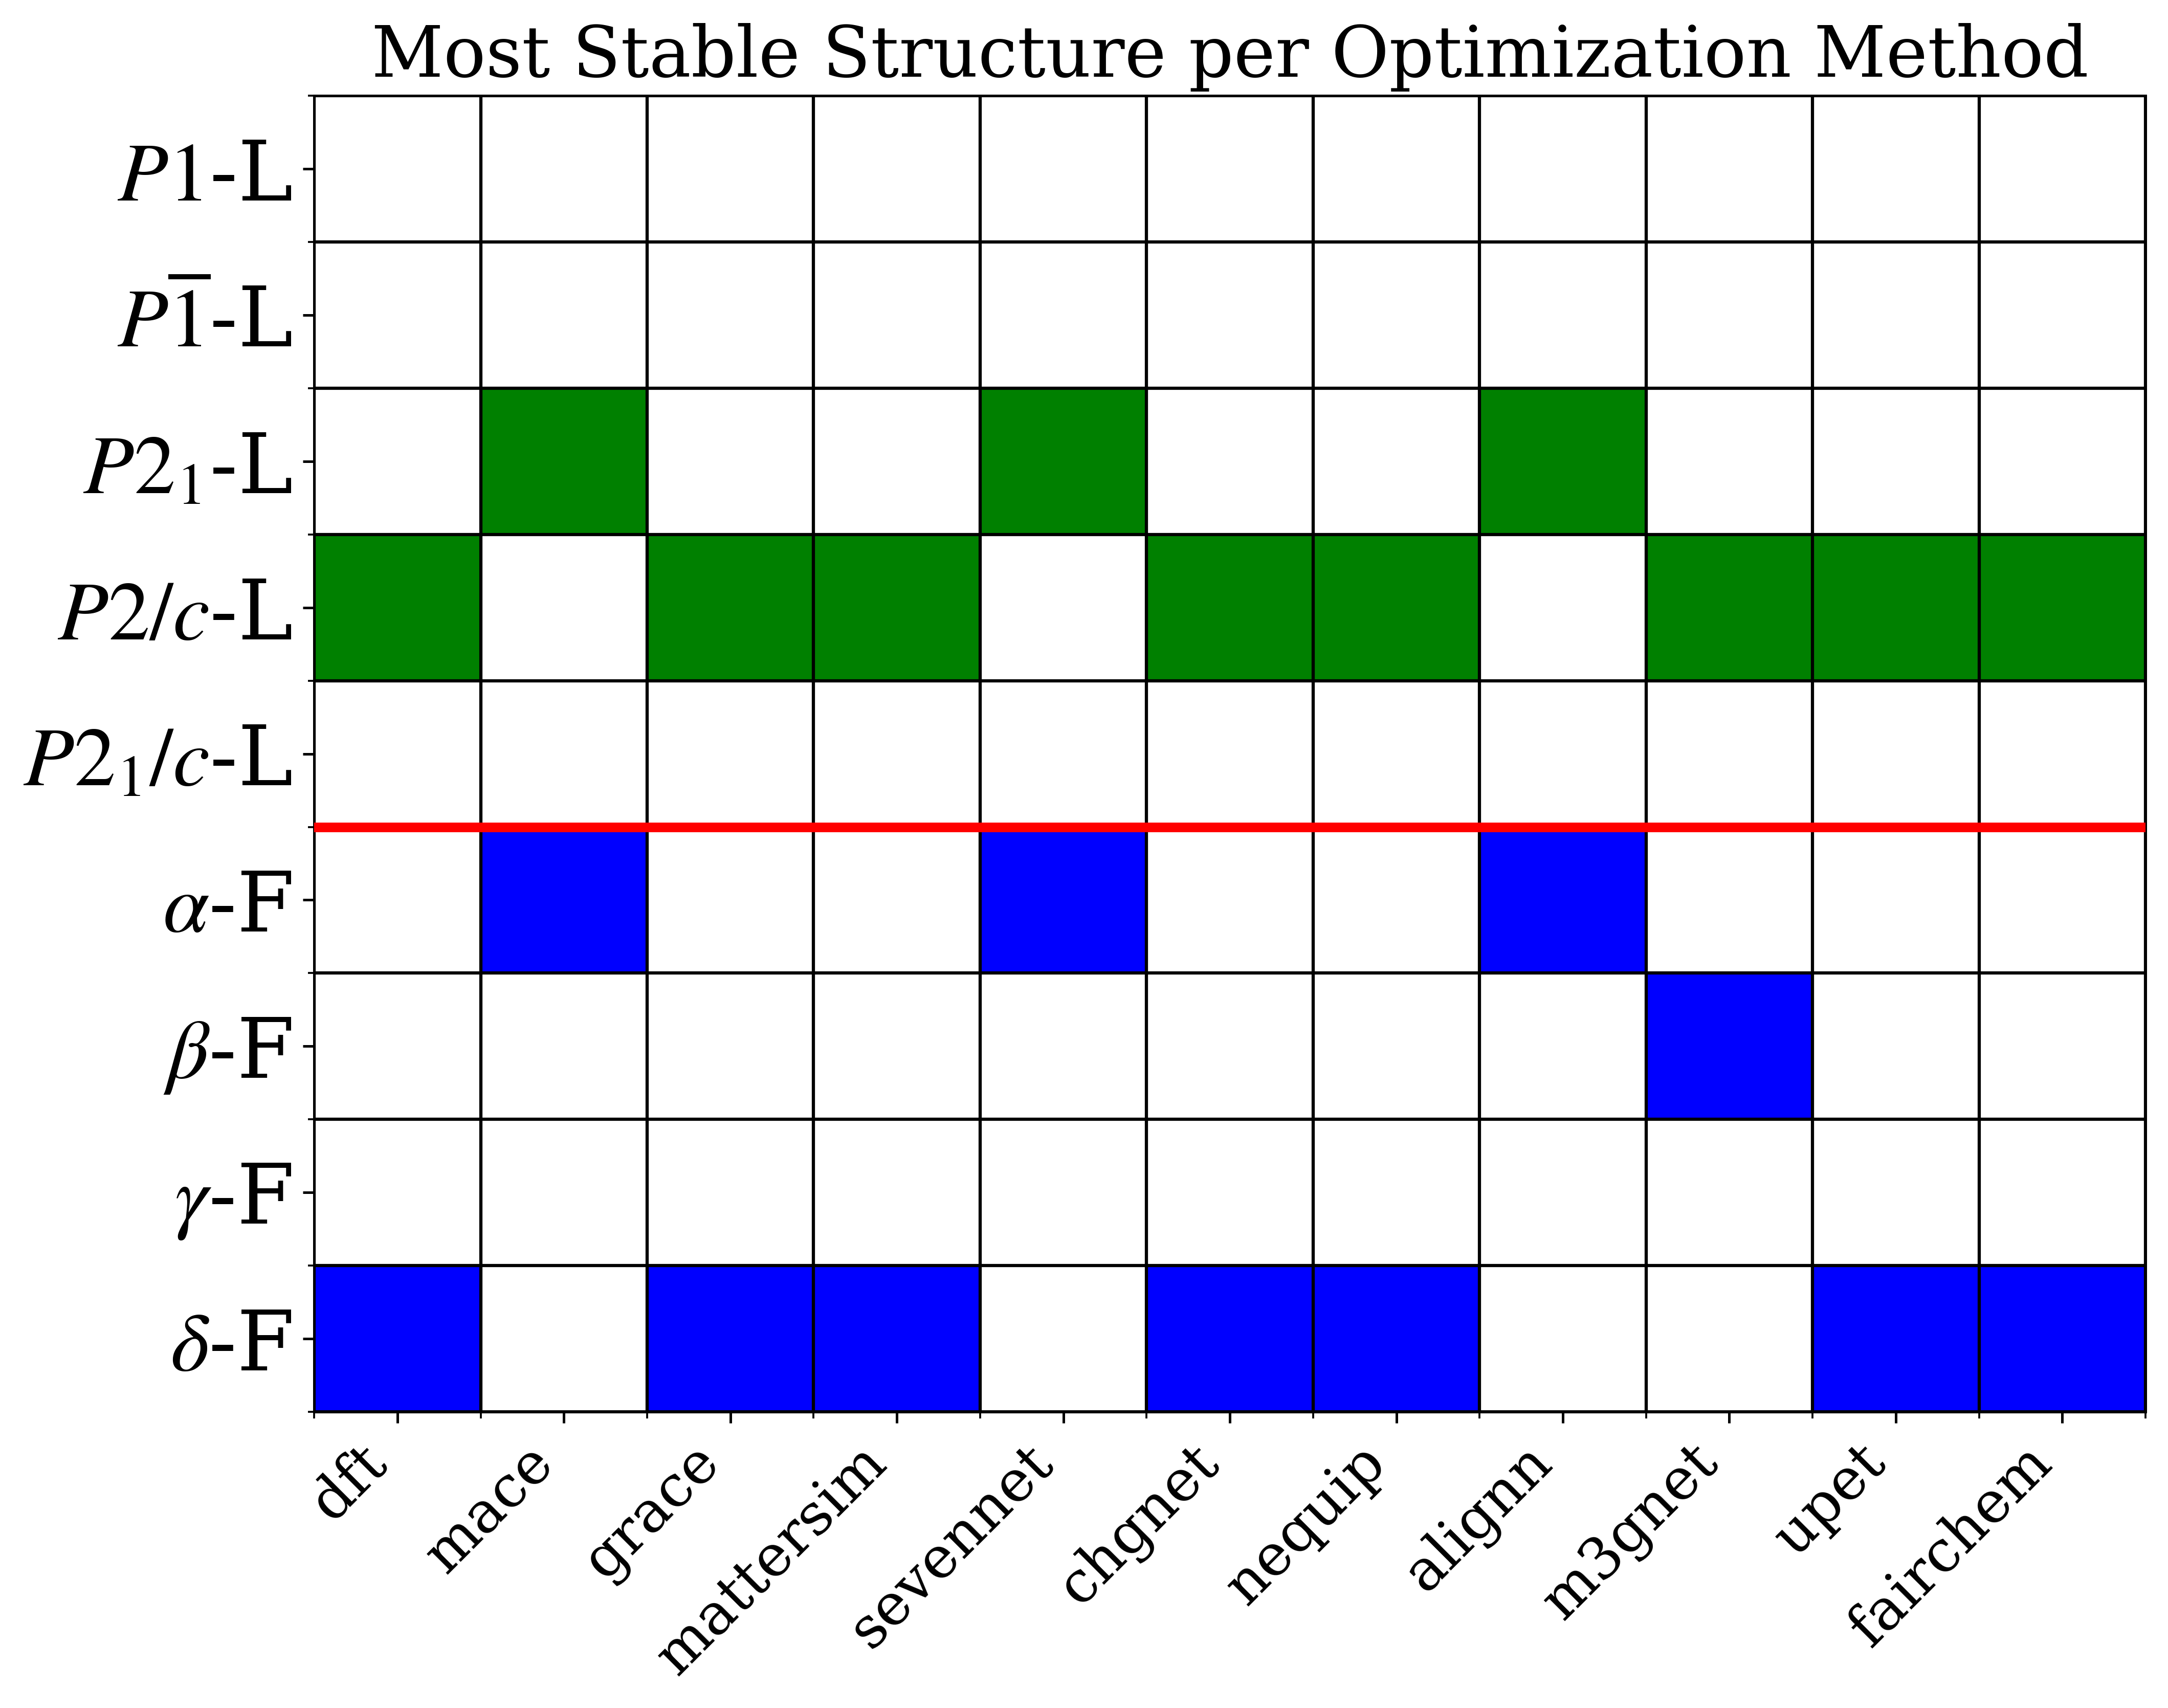

In [268]:
# Use CONSISTENT method names
methods = list(data_all.keys())  # 11 methods
n_methods = len(methods)  # Match your data

# ... your heatmap_data creation ...

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_data[:, :n_methods], cmap=cmap, aspect='auto', vmin=0, vmax=2)  # Match columns

# Gridlines FIRST
ax.set_xticks(np.arange(n_methods + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(n_structures + 1) - 0.5, minor=True)
ax.grid(which='minor', color='black', linestyle='-', linewidth=1)

# REMOVED MaxNLocator - use exact ticks
ax.set_xticks(np.arange(n_methods))  # Exactly 11 ticks
ax.set_xticklabels(methods, fontsize=18, rotation=45, ha='right')  # Exactly 11 labels
ax.set_xticklabels(methods, fontsize=18, )  # Exactly 11 labels

ax.set_yticks(list(range(0,len(names_plot))))  # Exactly 11 ticks
ax.set_yticklabels(names_plot)
ax.axhline(y=4.5, color='red', linewidth=3, zorder=10)
ax.set_title('Most Stable Structure per Optimization Method', fontsize=22)

plt.tight_layout()

fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/guess_map.png", dpi=450)
fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/guess_map.pdf", dpi=450)

plt.show()





### Atomic positions

In [208]:
st_names = ["layered_p1", "layered_p-1", "layered_p2c", "layered_p21", "layered_p21c", "alpha", "beta", "gamma", "delta"]

In [211]:
path_dft = "/home/a.burov/icys_2025/niohf/optimized/dft/"
path_sevennet = "/home/a.burov/icys_2025/niohf/optimized/sevenn/"
path_chgnet = "/home/a.burov/icys_2025/niohf/optimized/chgnet/"

path_alignn = "/home/a.burov/icys_2025/niohf/optimized/alignn/"
path_fairchem = "/home/a.burov/icys_2025/niohf/optimized/fairchem/"
path_grace = "/home/a.burov/icys_2025/niohf/optimized/grace/"
path_m3gnet = "/home/a.burov/icys_2025/niohf/optimized/m3gnet/"
path_mace = "/home/a.burov/icys_2025/niohf/optimized/mace/"
path_mattersim = "/home/a.burov/icys_2025/niohf/optimized/mattersim/"
path_nequip = "/home/a.burov/icys_2025/niohf/optimized/nequip/"
path_upet = "/home/a.burov/icys_2025/niohf/optimized/upet/"


In [212]:
diffs_dir = {}

for name in st_names:
    # st_dft = smart_structure_read(path_dft + name + ".POSCAR")
    st_dft = smart_structure_read(path_dft + name + ".vasp")
    st_sevennet = smart_structure_read(path_sevennet + name + ".vasp")
    st_chgnet = smart_structure_read(path_chgnet + name + ".vasp")

    coords_dft = np.array(st_dft.xred)
    coords_sevennet = np.array(st_sevennet.xred)
    coords_chgnet = np.array(st_chgnet.xred)

    frac_diff = coords_sevennet - coords_dft
    frac_diff_sevennet = frac_diff - np.round(frac_diff)
    distance_sevennet = np.linalg.norm(frac_diff_sevennet)

    frac_diff = coords_chgnet - coords_dft
    frac_diff_chgnet = frac_diff - np.round(frac_diff)
    distance_chgnet = np.linalg.norm(frac_diff_chgnet)

    # print(distance_sevennet, distance_chgnet, )

    diffs_dir[name] = {}
    diffs_dir[name]["sevennet"] = np.sum(frac_diff_sevennet**2, axis=1)**0.5
    diffs_dir[name]["chgnet"] = np.sum(frac_diff_chgnet**2, axis=1)**0.5
    
    

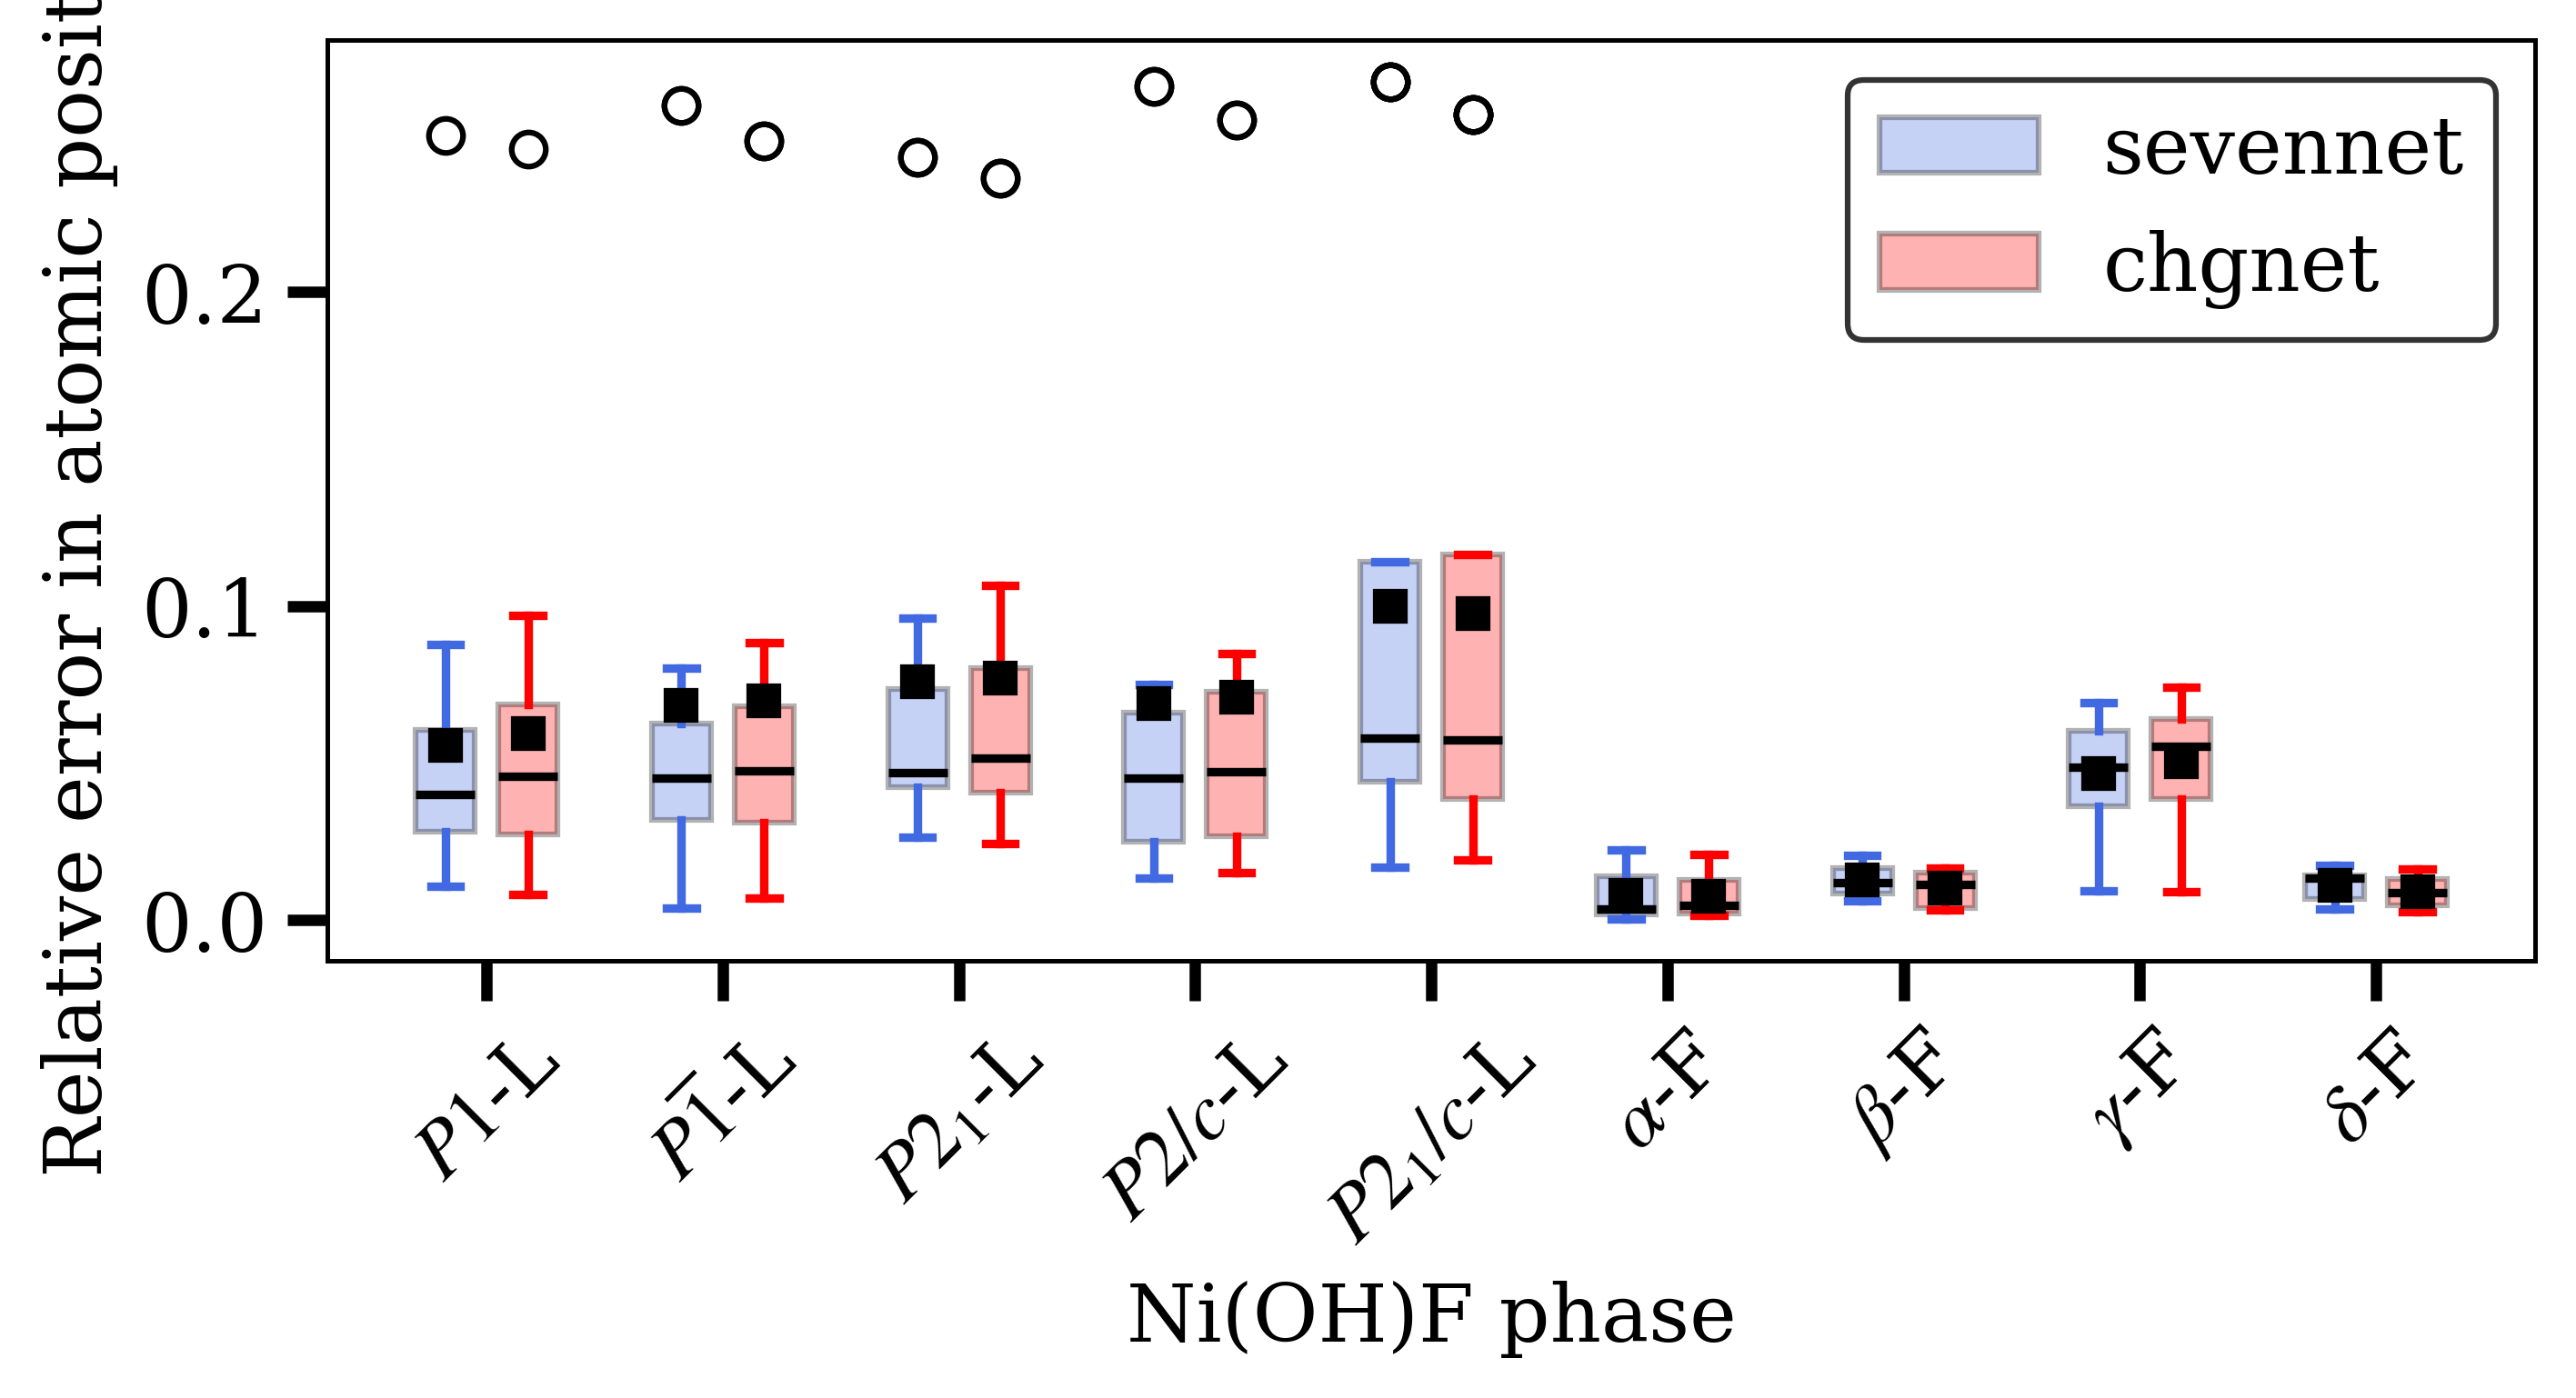

In [219]:
fontsize = 14
lw = 2.0

phases = list(diffs_dir.keys())
seven = [diffs_dir[p]['sevennet'] for p in phases]
chg   = [diffs_dir[p]['chgnet']   for p in phases]

x = np.arange(len(phases), dtype=float)
width = 0.35

fig, ax = plt.subplots(figsize=(7,4))
# draw two sets of boxplots with small offsets
bp1 = ax.boxplot(seven, positions=x - width/2, widths=0.25, patch_artist=True, showmeans=True)
bp2 = ax.boxplot(chg,   positions=x + width/2, widths=0.25, patch_artist=True, showmeans=True)

# color/legend
for b in bp1['boxes']:
    b.set_facecolor('royalblue')
    b.set_alpha(0.3)
for cap in bp1['caps']:
    cap.set(color="royalblue", linewidth=1.5)
for whisker in bp1['whiskers']:
    whisker.set(color="royalblue", linewidth=1.5)
for median in bp1['medians']:
    median.set(color="black", linewidth=1.5)
for mean in bp1['means']:
    mean.set(marker='s', markeredgecolor="black", markerfacecolor="black", markersize=5)

for b in bp2['boxes']:
    b.set_facecolor('red')
    b.set_alpha(0.3)
for cap in bp2['caps']:
    cap.set(color="red", linewidth=1.5)
for whisker in bp2['whiskers']:
    whisker.set(color="red", linewidth=1.5)
for median in bp2['medians']:
    median.set(color="black", linewidth=1.5)
for mean in bp2['means']:
    mean.set(marker='s', markeredgecolor="black", markerfacecolor="black", markersize=5)


ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.tick_params(axis='both', which='minor', labelsize=fontsize-2)
ax.yaxis.get_offset_text().set_fontsize(10)
ax.xaxis.set_tick_params(width=2, length=7)
ax.yaxis.set_tick_params(width=2, length=7)

ax.set_xticks(x)
ax.set_xticklabels(names_plot, rotation=45)
ax.set_xlabel('Ni(OH)F phase', fontsize=fontsize)
ax.set_ylabel('Relative error in atomic positions', fontsize=fontsize)
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['sevennet', 'chgnet'], 
          loc=(1), edgecolor="black", fontsize=fontsize)


fig.tight_layout()
plt.show()

fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/atomic_pos_old.png", dpi=450)
fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/atomic_pos_old.pdf", dpi=450)



In [ ]:
path_dft = "/home/a.burov/icys_2025/niohf/optimized/dft/"


In [220]:
# Dictionary of ALL potentials (10 total)
potentials = {
    "sevennet": "/home/a.burov/icys_2025/niohf/optimized/sevenn/",
    "chgnet": "/home/a.burov/icys_2025/niohf/optimized/chgnet/",
    "alignn": "/home/a.burov/icys_2025/niohf/optimized/alignn/",
    "fairchem": "/home/a.burov/icys_2025/niohf/optimized/fairchem/",
    "grace": "/home/a.burov/icys_2025/niohf/optimized/grace/",
    "m3gnet": "/home/a.burov/icys_2025/niohf/optimized/m3gnet/",
    "mace": "/home/a.burov/icys_2025/niohf/optimized/mace/",
    "mattersim": "/home/a.burov/icys_2025/niohf/optimized/mattersim/",
    "nequip": "/home/a.burov/icys_2025/niohf/optimized/nequip/",
    "upet": "/home/a.burov/icys_2025/niohf/optimized/upet/"
}


In [221]:
diffs_dir = {}

for name in st_names:
    st_dft = smart_structure_read(path_dft + name + ".vasp")
    coords_dft = np.array(st_dft.xred)
    
    diffs_dir[name] = {}
    
    # Loop over ALL potentials
    for pot_name, pot_path in potentials.items():
        st_pot = smart_structure_read(pot_path + name + ".vasp")
        coords_pot = np.array(st_pot.xred)
        
        # Calculate fractional differences (minimum image)
        frac_diff = coords_pot - coords_dft
        frac_diff_minimg = frac_diff - np.round(frac_diff)
        per_atom_distances = np.sum(frac_diff_minimg**2, axis=1)**0.5
        
        diffs_dir[name][pot_name] = per_atom_distances
    
    print(f"Processed {name}: {list(potentials.keys())}")


Processed layered_p1: ['sevennet', 'chgnet', 'alignn', 'fairchem', 'grace', 'm3gnet', 'mace', 'mattersim', 'nequip', 'upet']
Processed layered_p-1: ['sevennet', 'chgnet', 'alignn', 'fairchem', 'grace', 'm3gnet', 'mace', 'mattersim', 'nequip', 'upet']
Processed layered_p2c: ['sevennet', 'chgnet', 'alignn', 'fairchem', 'grace', 'm3gnet', 'mace', 'mattersim', 'nequip', 'upet']
Processed layered_p21: ['sevennet', 'chgnet', 'alignn', 'fairchem', 'grace', 'm3gnet', 'mace', 'mattersim', 'nequip', 'upet']
Processed layered_p21c: ['sevennet', 'chgnet', 'alignn', 'fairchem', 'grace', 'm3gnet', 'mace', 'mattersim', 'nequip', 'upet']
Processed alpha: ['sevennet', 'chgnet', 'alignn', 'fairchem', 'grace', 'm3gnet', 'mace', 'mattersim', 'nequip', 'upet']
Processed beta: ['sevennet', 'chgnet', 'alignn', 'fairchem', 'grace', 'm3gnet', 'mace', 'mattersim', 'nequip', 'upet']
Processed gamma: ['sevennet', 'chgnet', 'alignn', 'fairchem', 'grace', 'm3gnet', 'mace', 'mattersim', 'nequip', 'upet']
Processed d

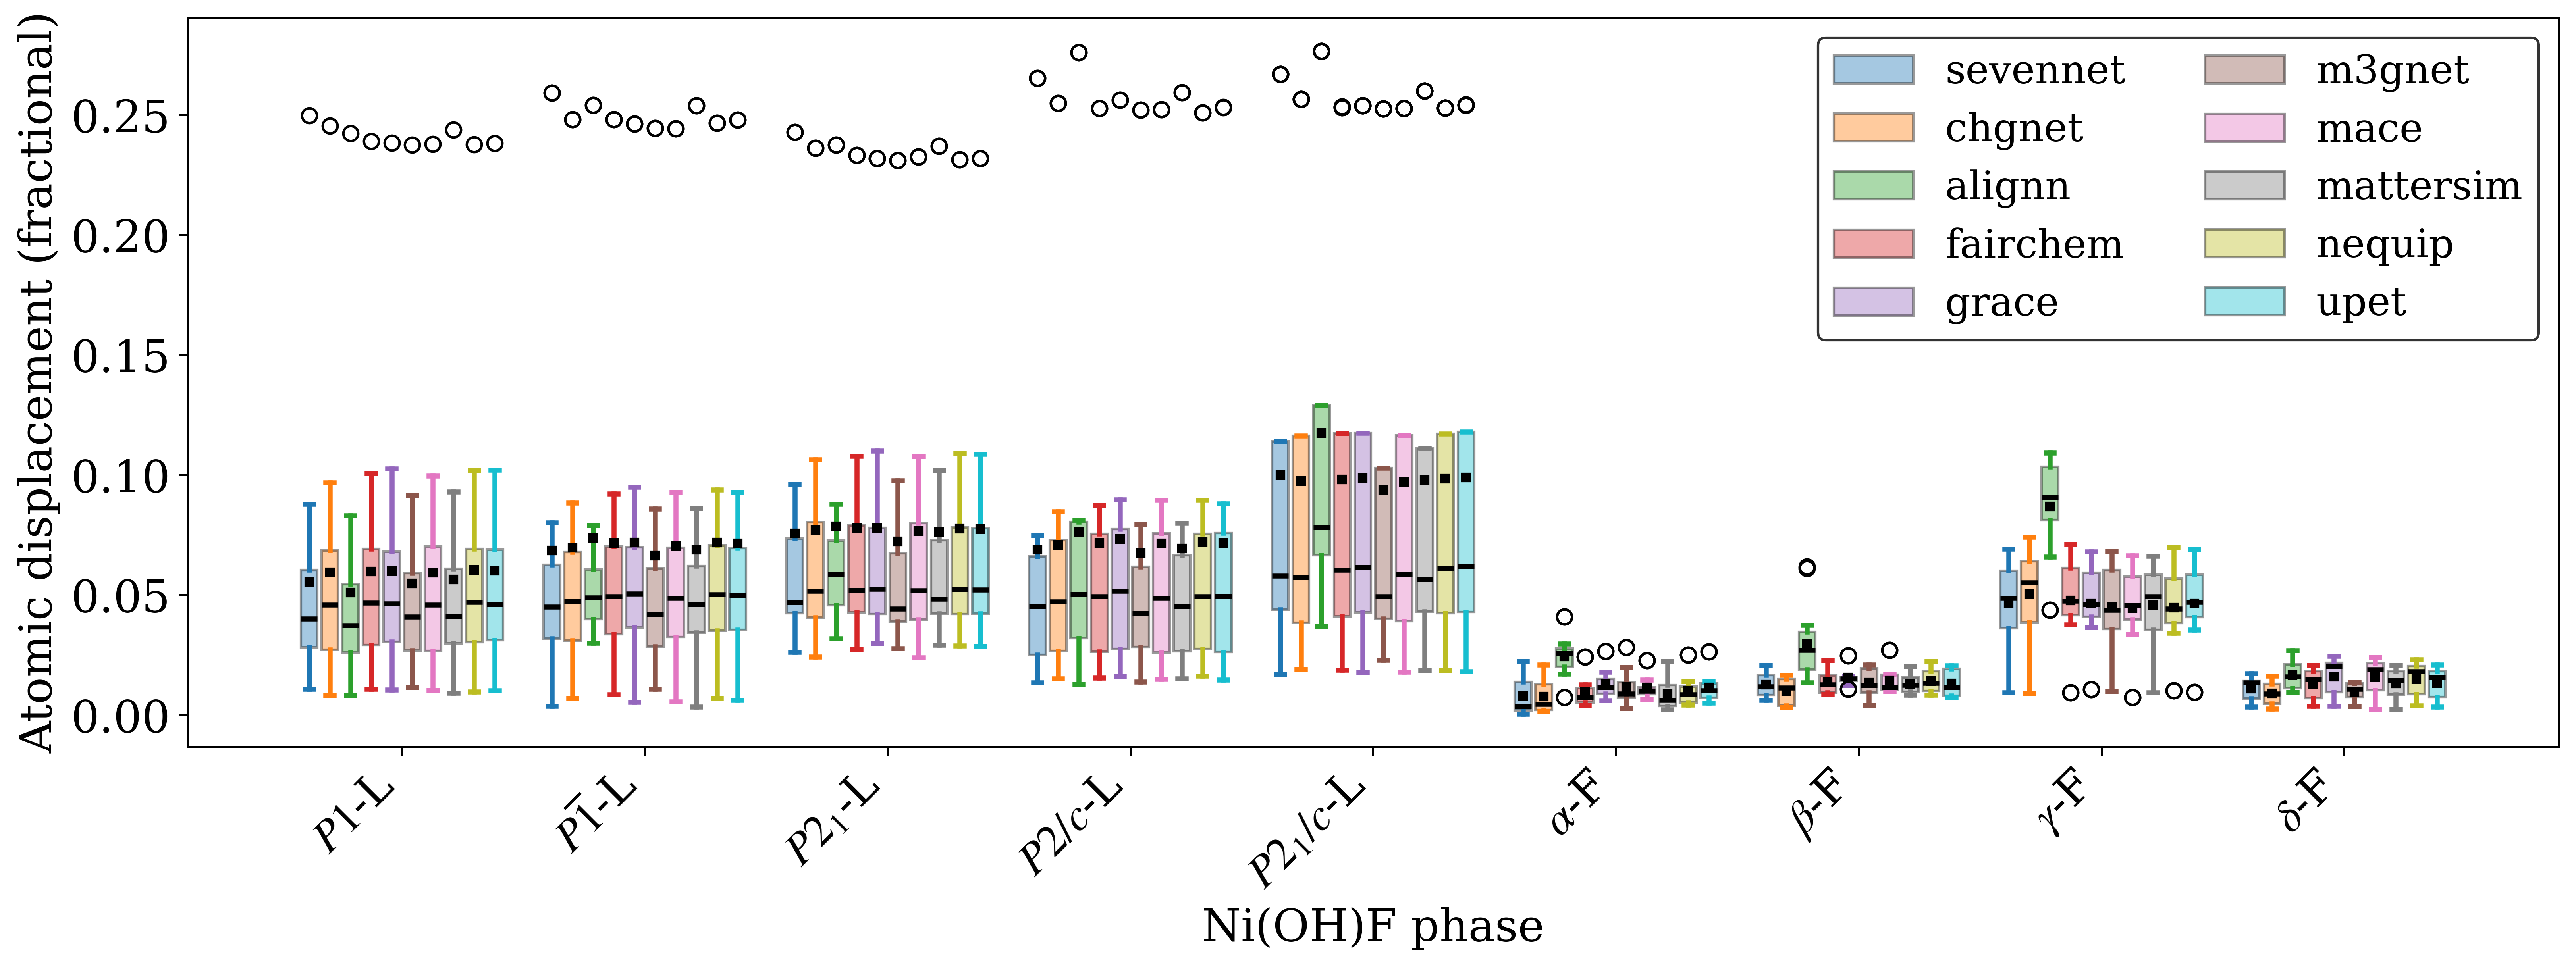

In [234]:
potentials_list = list(potentials.keys())  # ['sevennet', 'chgnet', 'alignn', ...]
n_pots = len(potentials_list)  # 10

fontsize = 18
lw = 2.0

phases = list(diffs_dir.keys())
data_all = {}  # Collect all data
for pot in potentials_list:
    data_all[pot] = [diffs_dir[p][pot] for p in phases]

x = np.arange(len(phases), dtype=float)
width = 0.85 / n_pots  # Dynamic width for 10 boxes

fig, ax = plt.subplots(figsize=(15, 6))  # Wider figure

# Colors for 10 potentials
colors = plt.cm.tab10(np.linspace(0, 1, n_pots))  # 10 distinct colors
box_plots = []

# Loop over ALL potentials
for i, pot_name in enumerate(potentials_list):
    bp = ax.boxplot(data_all[pot_name], 
                   positions=x + (i - n_pots/2 + 0.5) * width,  # Center groups
                   widths=width*0.8, patch_artist=True, showmeans=True)
    box_plots.append(bp)
    
    # Color styling
    box_color = colors[i]
    for b in bp['boxes']:
        b.set_facecolor(box_color)
        b.set_alpha(0.4)
    for part in ['caps', 'whiskers']:
        [item.set(color=box_color, linewidth=lw) for item in bp[part]]
    for median in bp['medians']:
        median.set(color="black", linewidth=lw)
    for mean in bp['means']:
        mean.set(marker='s', markeredgecolor="black", markerfacecolor="black", markersize=3)


# Formatting
ax.set_xticks(x)
ax.set_xticklabels(names_plot, rotation=45, ha='right')
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_xlabel('Ni(OH)F phase', fontsize=fontsize)
ax.set_ylabel('Atomic displacement (fractional)', fontsize=fontsize)
ax.yaxis.get_offset_text().set_fontsize(10)

# Legend using first box of each
legend_elements = [bp['boxes'][0] for bp in box_plots]
ax.legend(legend_elements, potentials_list, loc=1, fontsize=fontsize-2, edgecolor='black', ncols=len(potentials.keys())//4)

plt.tight_layout()
plt.savefig("/home/a.burov/icys_2025/niohf/data/figures/atomic_pos_all.png", dpi=450, bbox_inches='tight')
plt.savefig("/home/a.burov/icys_2025/niohf/data/figures/atomic_pos_all.pdf", dpi=450, bbox_inches='tight')

plt.show()


### RMSE errors 

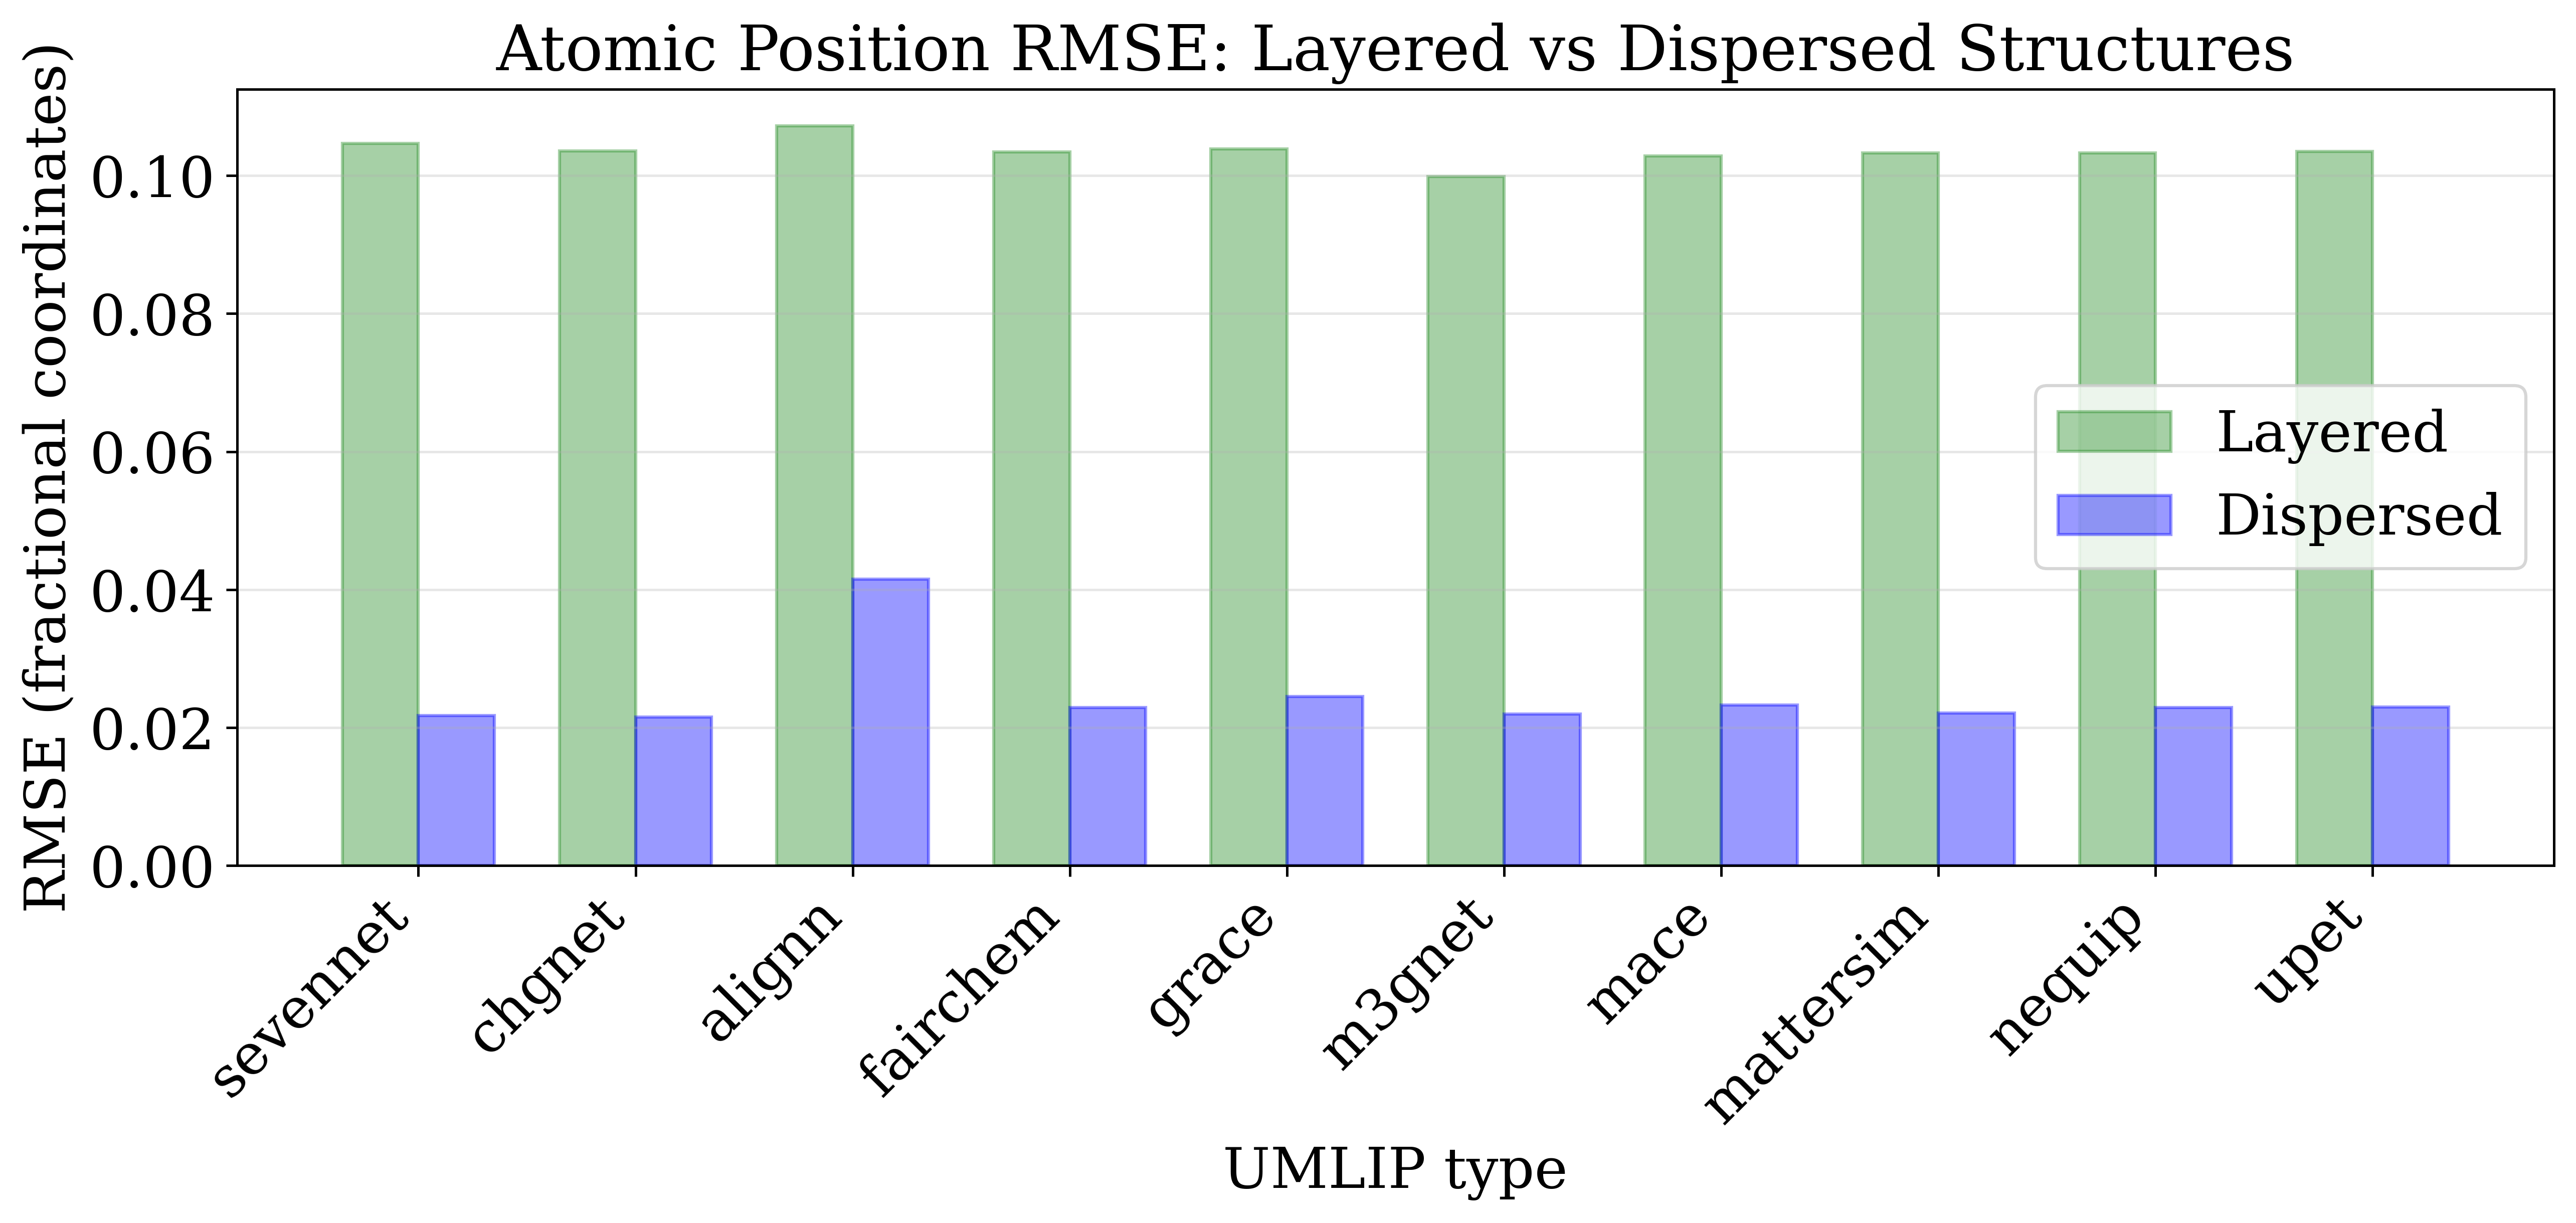

In [243]:
potentials_list = list(potentials.keys())  # ['sevennet', 'chgnet', 'alignn', ...]
phases = list(diffs_dir.keys())
n_pots = len(potentials_list)
n_struct_types = 2  # layered, dispersed

# Split structures into layered (0-4) and dispersed (5-8)
layered_phases = phases[:5]
dispersed_phases = phases[5:]

# Calculate RMSE for each potential + structure type
rmse_data = {}
for pot in potentials_list:
    # RMSE = sqrt(mean(per_atom_distance**2))
    layered_rmse = [np.sqrt(np.mean(diffs_dir[p][pot]**2)) for p in layered_phases]
    dispersed_rmse = [np.sqrt(np.mean(diffs_dir[p][pot]**2)) for p in dispersed_phases]
    rmse_data[pot] = {'layered': np.mean(layered_rmse), 'dispersed': np.mean(dispersed_rmse)}

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(n_pots)
width = 0.35
fontsize = 18

# Layered bars (left)
layered_vals = [rmse_data[pot]['layered'] for pot in potentials_list]
bars1 = ax.bar(x - width/2, layered_vals, width, label='Layered', alpha=0.4, edgecolor='forestgreen', color="forestgreen")

# Dispersed bars (right)  
dispersed_vals = [rmse_data[pot]['dispersed'] for pot in potentials_list]
bars2 = ax.bar(x + width/2, dispersed_vals, width, label='Dispersed', alpha=0.4, edgecolor='blue', color="blue")

# Formatting
ax.set_xlabel('UMLIP type', fontsize=fontsize)
ax.set_ylabel('RMSE (fractional coordinates)', fontsize=fontsize)
ax.set_title('Atomic Position RMSE: Layered vs Dispersed Structures', fontsize=fontsize+2)
ax.set_xticks(x)
ax.set_xticklabels(potentials_list, rotation=45, ha='right')
ax.tick_params(axis='both', labelsize=fontsize)
ax.legend(fontsize=fontsize, loc=7)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
# for bar in bars1:
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
#             f'{height:.3f}', ha='center', va='bottom', fontsize=10)
    
# for bar in bars2:
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
#             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("/home/a.burov/icys_2025/niohf/data/figures/rmse_layered_dispersed.png", dpi=450, bbox_inches='tight')
plt.savefig("/home/a.burov/icys_2025/niohf/data/figures/rmse_layered_dispersed.pdf", dpi=450, bbox_inches='tight')
plt.show()




## Attempt to increase symmetry

In [24]:
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.core import Structure


In [34]:
# Load your structure
# structure = Structure.from_file('/home/a.burov/icys_2025/niohf/optimized/sevenn/layered.cif')
structure = Structure.from_file('/home/a.burov/icys_2025/niohf/optimized/dft/delta.cif')

# structure = Structure.from_file('/home/a.burov/icys_2025/niohf/initial_no_relaxation/CuOHF.cif')



In [35]:
# Symmetrize with looser tolerance
sga = SpacegroupAnalyzer(structure, symprec=0.1, angle_tolerance=30)
symmetrized_structure = sga.get_refined_structure()

# Check symmetry improvement
print(f"Original space group: {SpacegroupAnalyzer(structure, symprec=0.01).get_space_group_symbol()}")
print(f"Refined space group: {sga.get_space_group_symbol()}")

# Save
# symmetrized_structure.to(filename='symmetrized.cif')


Original space group: Pmc2_1
Refined space group: Pmc2_1


In [29]:
symmetrized_structure

Structure Summary
Lattice
    abc : 3.0677600000000007 4.619330000000001 10.14106
 angles : 90.0 90.0 90.0
 volume : 143.7089186756609
      A : np.float64(3.0677600000000007) np.float64(0.0) np.float64(0.0)
      B : np.float64(0.0) np.float64(4.619330000000001) np.float64(0.0)
      C : np.float64(0.0) np.float64(0.0) np.float64(10.14106)
    pbc : True True True
PeriodicSite: Ni (0.0, 1.043, 3.685) [0.0, 0.2257, 0.3634]
PeriodicSite: Ni (0.0, 3.577, 8.756) [0.0, 0.7743, 0.8634]
PeriodicSite: Ni (1.534, 1.226, 6.395) [0.5, 0.2654, 0.6306]
PeriodicSite: Ni (1.534, 3.393, 1.324) [0.5, 0.7346, 0.1306]
PeriodicSite: H (0.0, 3.917, 5.83) [0.0, 0.848, 0.5749]
PeriodicSite: H (0.0, 0.7021, 0.7596) [0.0, 0.152, 0.0749]
PeriodicSite: H (1.534, 3.021, 4.523) [0.5, 0.654, 0.446]
PeriodicSite: H (1.534, 1.598, 9.593) [0.5, 0.346, 0.946]
PeriodicSite: O (0.0, 0.1945, 5.594) [0.0, 0.0421, 0.5516]
PeriodicSite: O (0.0, 4.425, 0.5233) [0.0, 0.9579, 0.0516]
PeriodicSite: O (1.534, 2.141, 4.582) [0.5,

## XRD profiles

In [ ]:
from pymatgen.core import Structure


In [ ]:
data_xrd_path = "/home/a.burov/icys_2025/niohf/data/NiOHF_clean_#01.gdf"

In [ ]:
with open(data_xrd_path, 'r', encoding='latin-1') as f:
    lines = f.readlines() 


In [ ]:
for idx, line in enumerate(lines):
    if '<beginc><endc>' in line:
        print(f"Found at line {idx}: {line.strip()}")
        break


In [ ]:
idx

In [ ]:
angle_min = float(lines[idx+1])
angle_max = float(lines[idx+2])
step = float(lines[idx+3])


In [ ]:
int_xrd = [int(inten) for inten in lines[idx+7:]]

In [ ]:
angles_xrd = [angle_min + (entry_num-idx-7)*step for entry_num in range(idx+7, len(lines), 1) ]


In [ ]:
# calculator = XRDCalculator(wavelength="CuKa", symprec=1e-10, 
#                debye_waller_factors={"Ni": 0.3, "O": 0.5, "H": 1.5, "F": 0.4})  # Cu Kα radiation (1.5406 Å)

calculator = XRDCalculator(wavelength="CoKa1", symprec=1e-10, 
               debye_waller_factors={"Ni": 0.3, "O": 0.5, "H": 1.5, "F": 0.4})  # Cu Kα radiation (1.5406 Å)


# Ni	0.3 - 0.5	Heavy transition metal, low thermal motion
# O	0.5 - 0.8	Moderate thermal motion in oxide framework
# H	1.5 - 2.5	Lightest atom, highest thermal displacement
# F	0.4 - 0.7  Similar to O, but slightly lower in fluorides


In [ ]:
# latt_scale_factor = 0.87
latt_scale_factor = 1.0


In [ ]:
structure_diaspore = db['delta.sc', '9bulk_eos', 100].copy().end
latt = np.array(structure_diaspore.rprimd)
structure_diaspore.rprimd = latt * latt_scale_factor
structure_diaspore.update_xcart()
structure_diaspore.update_xred()


In [ ]:
structure_diaspore = structure_diaspore.convert2pymatgen()
pattern_diaspore = calculator.get_pattern(structure_diaspore, two_theta_range=(0, 100))


In [ ]:
structure_layered = db["layered", '9bulk', 1].copy().end
structure_layered = structure_layered.get_conventional_cell()
latt = np.array(structure_layered.rprimd)
structure_layered.rprimd = latt * latt_scale_factor
structure_layered.update_xcart()
structure_layered.update_xred()



In [ ]:
structure_layered = structure_layered.convert2pymatgen()

pattern_layered = calculator.get_pattern(structure_layered, two_theta_range=(0, 100))


In [ ]:
st_layered = Structure.from_file("/home/a.burov/icys_2025/niohf/optimized/sevenn/layered.cif")

In [ ]:
# structure_layered = db["layered", '9bulk', 1].copy().end
# structure_layered.write_cif("/home/a.burov/icys_2025/niohf/data/layered_dft.cif")

In [ ]:
int_list = pattern_layered.as_dict()["y"]
theta_list = pattern_layered.as_dict()["x"]

hkl_list = []
for mill_idx in pattern_layered.as_dict()["hkls"]: 
    hkl_cur = mill_idx[0]['hkl'] 
    hkl_cur = [str(hkl) for hkl in hkl_cur ]
    hkl_cur = "".join(hkl_cur)
    hkl_list.append(hkl_cur)


In [ ]:
fontsize = 14
lw = 2.0
width = 0.3

fig, ax = plt.subplots(1, 1, figsize=(7, 4), dpi=600)
plt.tight_layout()


# Add titles and labels
ax.set_ylabel(r'Intensity', fontsize=fontsize)
ax.set_xlabel(r'$2\Theta$, degrees', fontsize=fontsize)

ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.tick_params(axis='both', which='minor', labelsize=fontsize-2)
ax.yaxis.get_offset_text().set_fontsize(10)
ax.xaxis.set_tick_params(width=2, length=7)
ax.yaxis.set_tick_params(width=2, length=7)

shift_angle = 0
ax.plot(angles_xrd, np.array(int_xrd)/max(int_xrd),  label='experiment')
plt.bar(pattern_layered.x + shift_angle, pattern_layered.y/max(pattern_layered.y), width=0.3, color='red', label='layered')
plt.bar(pattern_diaspore.x + shift_angle, pattern_diaspore.y/max(pattern_diaspore.y), width=0.3, color='green', label='diaspore')

plt.legend(fontsize=fontsize-4, loc=1)


fig.tight_layout()
fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/xrd_both.png", dpi=450)



## Single-phase sample

In [ ]:
exp_data = np.loadtxt("/home/a.burov/icys_2025/niohf/data/Ni(OH)F_8h_50ml.xy")
# Assign to arrays
angles_list = exp_data[:, 0]  # First column
int_list = exp_data[:, 1]     # Second column

In [ ]:
calculator = XRDCalculator(wavelength="CuKa1", symprec=1e-10, 
               debye_waller_factors={"Ni": 0.3, "O": 0.5, "H": 1.5, "F": 0.4})  # Cu Kα radiation (1.5406 Å)


In [ ]:
structure_layered = db["layered", '9bulk', 1].copy().end
# structure_layered = structure_layered.get_conventional_cell()
structure_layered = structure_layered.get_primitive_cell()


In [ ]:
structure_layered = structure_layered.convert2pymatgen()


In [ ]:
pattern_layered = calculator.get_pattern(structure_layered, two_theta_range=(0, 100))


In [ ]:
hkl_list = []
for mill_idx in pattern_layered.as_dict()["hkls"]: 
    hkl_cur = mill_idx[0]['hkl'] 
    hkl_cur = [str(hkl) for hkl in hkl_cur ]
    hkl_cur = "".join(hkl_cur)
    hkl_list.append(hkl_cur)


In [ ]:
hkl_list

In [ ]:
fontsize = 14
lw = 2.0
width = 0.3

fig, ax = plt.subplots(1, 1, figsize=(7, 4), dpi=600)
plt.tight_layout()


# Add titles and labels
ax.set_ylabel(r'Intensity', fontsize=fontsize)
ax.set_xlabel(r'$2\Theta$, degrees', fontsize=fontsize)

ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.tick_params(axis='both', which='minor', labelsize=fontsize-2)
ax.yaxis.get_offset_text().set_fontsize(10)
ax.xaxis.set_tick_params(width=2, length=7)
ax.yaxis.set_tick_params(width=2, length=7)

shift_angle = 0
ax.plot(angles_list, np.array(int_list)/max(int_list),  label='experiment', zorder=1)
plt.bar(pattern_layered.x + shift_angle, pattern_layered.y/max(pattern_layered.y), width=0.2, color='red', label='layered', zorder=2)

plt.legend(fontsize=10, loc=1)


fig.tight_layout()
fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/xrd_layered.png", dpi=450)


### LNO test with Co source

In [ ]:
import pymatgen as pm
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from pymatgen.io.ase import AseAtomsAdaptor


In [ ]:
exp_data = np.loadtxt("/home/a.burov/icys_2025/niohf/data/LNO1_A.xyd")
# Assign to arrays
angles_list = exp_data[:, 0]  # First column
int_list = exp_data[:, 1]     # Second column

In [ ]:
st_ase = read("/home/a.burov/icys_2025/niohf/data/LNO.cif")


In [ ]:
structure_lno = AseAtomsAdaptor.get_structure(st_ase)


In [ ]:
structure_lno.get_space_group_info()

In [ ]:
xrd = XRDCalculator(wavelength="CoKa") #initiate XRD calculator (can specify various options here)
structure_lno_pattern = xrd.get_pattern(structure_lno, scaled=True, two_theta_range=(0, 100))


In [ ]:
structure_lno_pattern

In [ ]:
hkl_list = []
for mill_idx in structure_lno_pattern.as_dict()["hkls"]: 
    hkl_cur = mill_idx[0]['hkl'] 
    hkl_cur = [str(hkl) for hkl in hkl_cur ]
    hkl_cur = "".join(hkl_cur)
    hkl_list.append(hkl_cur)

print(hkl_list)




In [ ]:
fontsize = 14
lw = 2.0
width = 0.3

fig, ax = plt.subplots(1, 1, figsize=(7, 5), dpi=600)
plt.tight_layout()


# Add titles and labels
ax.set_ylabel(r'Intensity', fontsize=fontsize)
ax.set_xlabel(r'$2\Theta$, degrees', fontsize=fontsize)

ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.tick_params(axis='both', which='minor', labelsize=fontsize-2)
ax.yaxis.get_offset_text().set_fontsize(10)
ax.xaxis.set_tick_params(width=2, length=7)
ax.yaxis.set_tick_params(width=2, length=7)

shift_angle = 0
ax.plot(angles_list, np.array(int_list)/max(int_list),  label='experiment', zorder=1)
plt.bar(structure_lno_pattern.x + shift_angle, structure_lno_pattern.y/max(structure_lno_pattern.y), width=0.2, color='red', label='LNO', zorder=2)

# plt.plot(tt, I, width=0.2, color='red', label='layered', zorder=2)

plt.legend(fontsize=10, loc=1)


fig.tight_layout()
fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/xrd_lno.png", dpi=450)




In [ ]:
write_database()

In [ ]:
# MP setup

In [ ]:
st = st_init.copy()

In [ ]:
add("layered", '9_bulk_mp', 1, it_folder = 'inter', input_st = st, cluster = 'razor128', up='up2', run=2)


## Defects

In [ ]:
!pip install pymatgen-analysis-defects



In [ ]:
from pymatgen.io.vasp import Chgcar

In [ ]:
from pymatgen.analysis.defects.generators import ChargeInterstitialGenerator


In [ ]:
cig = ChargeInterstitialGenerator()

In [ ]:
chg_path = "/home/a.burov/icys_2025/niohf/layered/layered.sc.9bulk_eos/100.CHGCAR"

In [ ]:
chg = Chgcar.from_file(chg_path)
    

In [ ]:
defects = list(cig.generate(chg, insert_species=["Li"]))
